La empresa ADL se dedica a la venta de productos a nivel regional en los Estados Unidos,
con equipos de ventas que operan en diferentes estados. La compañía ha establecido un
sistema de comisiones para incentivar a sus equipos de ventas a preferir la venta de
productos de alto margen antes que los de bajo margen de utilidad.
Como Analista de Datos, le solicitan analizar información sobre las ventas realizadas por
los equipos de ventas de ADL, incluyendo detalles sobre los productos vendidos, los
clientes, las fechas de los pedidos y los plazos de entrega.
Para resolver este desafío deberás cargar datos desde Hojas de Excel del archivo
US_Regional_Sales_Data.xlsx. En base a esto, debe generar una visualización de datos
como la que se muestra en las hojas Reporte1 y Reporte2 del archivo reporte.xlsx.
Para cumplir con lo solicitado, puedes aplicar los siguientes pasos:

In [ ]:
# 1. Carga los datos de cada pestaña del archivo US_Regional_Sales_Data.xlsx en un
#DataFrame independiente. (hint: Puedes obtener los nombres de las hojas usando
#pd.ExcelFile(archivo).sheet_names)

In [15]:
import pandas as pd

# Definimos la ruta del archivo
archivo = "US_Regional_Sales_Data.xlsx"

# 1. Creamos el objeto ExcelFile para leer la estructura del archivo
excel_obj = pd.ExcelFile(archivo)

# 2. Obtenemos de forma dinámica los nombres de todas las hojas (usando el hint)
nombres_hojas = excel_obj.sheet_names
print("Hojas encontradas en el archivo:", nombres_hojas)

# 3. Cargamos cada pestaña en un DataFrame independiente
# Usaremos un diccionario para automatizar la carga y mantener el código limpio
dataframes_cargados = {}

for nombre in nombres_hojas:
    # parse() lee la pestaña específica y la convierte en DataFrame
    dataframes_cargados[nombre] = excel_obj.parse(nombre)
    print(f"-> Hoja '{nombre}' cargada exitosamente. Filas: {dataframes_cargados[nombre].shape[0]}, Columnas: {dataframes_cargados[nombre].shape[1]}")

# 4. Asignamos cada DataFrame a una variable independiente para facilitar el análisis posterior
# Nota: Ajusta los nombres de las claves de acuerdo a los que se imprimieron en el paso anterior.
df_sales_orders = dataframes_cargados.get('Sales Orders Sheet')
df_customers    = dataframes_cargados.get('Customers Sheet')
df_products     = dataframes_cargados.get('Products Sheet')
df_regions      = dataframes_cargados.get('Store Locations Sheet')
df_sales_team   = dataframes_cargados.get('Sales Team Sheet')

Hojas encontradas en el archivo: ['Sales Orders Sheet', 'Customers Sheet', 'Store Locations Sheet', 'Products Sheet', 'Sales Team Sheet']
-> Hoja 'Sales Orders Sheet' cargada exitosamente. Filas: 7991, Columnas: 16
-> Hoja 'Customers Sheet' cargada exitosamente. Filas: 50, Columnas: 2
-> Hoja 'Store Locations Sheet' cargada exitosamente. Filas: 367, Columnas: 15
-> Hoja 'Products Sheet' cargada exitosamente. Filas: 47, Columnas: 2
-> Hoja 'Sales Team Sheet' cargada exitosamente. Filas: 28, Columnas: 3


In [ ]:
# 2. Cruza todos los DataFrames usando validación many_to_one, y guarda el resultado
#en una nueva variable llamada df_base

In [30]:
# Partimos de la tabla principal de transacciones (ventas)
# df_sales_orders representa el lado "many"

# 1. Cruzar con Clientes (Customers)
df_base = pd.merge(
    df_sales_orders,
    df_customers,
    left_on='_CustomerID',       # Llave común en df_sales_orders
    right_on='_CustomerID',     # Llave común en df_customers
    how='left',
    validate='many_to_one'      # Valida que df_sales_orders tiene "many" y df_customers tiene "one" por cada Customer ID
)

# 2. Cruzar con Productos (Products)
df_base = pd.merge(
    df_base,
    df_products,
    left_on='_ProductID',        # Llave común en df_base (proveniente de df_sales_orders)
    right_on='_ProductID',      # Llave común en df_products
    how='left',
    validate='many_to_one'
)

# 3. Cruzar con el Equipo de Ventas (Sales Team)
df_base = pd.merge(
    df_base,
    df_sales_team,
    left_on='_SalesTeamID',    # Llave común en df_base (proveniente de df_sales_orders)
    right_on='_SalesTeamID',    # Llave común en df_sales_team
    how='left',
    validate='many_to_one'
)

# 4. Cruzar con Regiones o Ubicaciones de Tiendas (Store Locations)
df_base = pd.merge(
    df_base,
    df_regions,
    left_on='_StoreID',          # Llave común en df_base (proveniente de df_sales_orders)
    right_on='_StoreID',        # Llave común en df_regions
    how='left',
    validate='many_to_one'
)

# --- Verificación de la integridad de df_base ---
print("=== Resumen de df_base ===")
print(f"Número total de registros (filas): {df_base.shape[0]}")
print(f"Número total de columnas: {df_base.shape[1]}")
display(df_base.head())

=== Resumen de df_base ===
Número total de registros (filas): 7991
Número total de columnas: 34


,OrderNumber,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,CurrencyCode,_SalesTeamID,_CustomerID,...,Type,Latitude,Longitude,AreaCode,Population,Household Income,Median Income,Land Area,Water Area,Time Zone
0,SO - 000101,In-Store,WARE-UHY1004,2017-12-31,2018-05-31,2018-06-14,2018-06-19,USD,6,15,...,Town,40.64092,-73.31669,631,213776,68789,80327,135481314,160302131,America/New York
1,SO - 000102,Online,WARE-NMK1003,2017-12-31,2018-05-31,2018-06-22,2018-07-02,USD,14,20,...,City,38.98223,-94.67079,913,186515,74830,72463,194562941,1309517,America/Chicago
2,SO - 000103,Distributor,WARE-UHY1004,2017-12-31,2018-05-31,2018-06-21,2018-07-01,USD,21,16,...,City,42.27087,-83.72633,734,117070,47179,55990,72727009,2254528,America/Detroit
3,SO - 000104,Wholesale,WARE-NMK1003,2017-12-31,2018-05-31,2018-06-02,2018-06-07,USD,28,48,...,City,41.30815,-72.92816,203,130322,49771,37192,48407373,3739487,America/New York
4,SO - 000105,Distributor,WARE-NMK1003,2018-04-10,2018-05-31,2018-06-16,2018-06-26,USD,22,49,...,City,41.55815,-73.05150,203,108802,40213,40467,73880017,1086045,America/New York


In [ ]:
# 3. Agrega las siguientes columnas a df_ base:
# Columna         / Cálculo
# ProcurementDays / OrderDate-ProcuredDate
# ShippingDays    / ShipDate-OrderDate
# DeliveryDays    / DeliveryDate-ShipDate
# CustomerDays    / ShippingDays+DeliveryDays

In [35]:
import numpy as np

# Asegurar que las columnas de fecha sean de tipo datetime
df_base['OrderDate'] = pd.to_datetime(df_base['OrderDate'])
df_base['ProcuredDate'] = pd.to_datetime(df_base['ProcuredDate'])
df_base['ShipDate'] = pd.to_datetime(df_base['ShipDate'])
df_base['DeliveryDate'] = pd.to_datetime(df_base['DeliveryDate'])

# Calcular ProcurementDays
df_base['ProcurementDays'] = (df_base['OrderDate'] - df_base['ProcuredDate']).dt.days

# Calcular ShippingDays
df_base['ShippingDays'] = (df_base['ShipDate'] - df_base['OrderDate']).dt.days

# Calcular DeliveryDays
df_base['DeliveryDays'] = (df_base['DeliveryDate'] - df_base['ShipDate']).dt.days

# Calcular CustomerDays
df_base['CustomerDays'] = df_base['ShippingDays'] + df_base['DeliveryDays']

# Mostrar las primeras filas con las nuevas columnas
print("=== df_base con nuevas columnas de días ===")
display(df_base[['OrderNumber', 'ProcuredDate', 'OrderDate', 'ShipDate', 'DeliveryDate', 'ProcurementDays', 'ShippingDays', 'DeliveryDays', 'CustomerDays']].head())

=== df_base con nuevas columnas de días ===


,OrderNumber,ProcuredDate,OrderDate,ShipDate,DeliveryDate,ProcurementDays,ShippingDays,DeliveryDays,CustomerDays
0,SO - 000101,2017-12-31,2018-05-31,2018-06-14,2018-06-19,151,14,5,19
1,SO - 000102,2017-12-31,2018-05-31,2018-06-22,2018-07-02,151,22,10,32
2,SO - 000103,2017-12-31,2018-05-31,2018-06-21,2018-07-01,151,21,10,31
3,SO - 000104,2017-12-31,2018-05-31,2018-06-02,2018-06-07,151,2,5,7
4,SO - 000105,2018-04-10,2018-05-31,2018-06-16,2018-06-26,51,16,10,26


In [ ]:
# 4. Agrega una nueva columna discreta al df_base, con el nombre CustomerDaysInterval
que clasifique los valores de la columna CustomerDays en los siguientes intervalos:
○ 0 to 15 days
○ 15 to 30 days
○ 30 to 45 days
○ 45 to 60 days
○ 60 to 75 days
○ 75 to 90 days
hint: Utiliza pd.cut con estas etiquetas de Intervalo. Puedes utilizar la propiedad
`.dt.days` para convertir la columna CustomerDays a valores numéricos. La
propiedad `.dt.days` te permite obtener directamente la representación numérica de
la diferencia en días a partir de un objeto DateInterval.

In [36]:
# Definir los límites de los intervalos (bins)
bins = [0, 15, 30, 45, 60, 75, 90, float('inf')] # Agregamos float('inf') para cubrir valores mayores a 90

# Definir las etiquetas para cada intervalo
labels = ['0 to 15 days', '15 to 30 days', '30 to 45 days', '45 to 60 days', '60 to 75 days', '75 to 90 days', 'Over 90 days']

# Crear la nueva columna 'CustomerDaysInterval' usando pd.cut
df_base['CustomerDaysInterval'] = pd.cut(df_base['CustomerDays'], bins=bins, labels=labels, right=False)

# Mostrar las primeras filas con la nueva columna para verificar
print("=== df_base con la nueva columna CustomerDaysInterval ===")
display(df_base[['OrderNumber', 'CustomerDays', 'CustomerDaysInterval']].head())

=== df_base con la nueva columna CustomerDaysInterval ===


,OrderNumber,CustomerDays,CustomerDaysInterval
0,SO - 000101,19,15 to 30 days
1,SO - 000102,32,30 to 45 days
2,SO - 000103,31,30 to 45 days
3,SO - 000104,7,0 to 15 days
4,SO - 000105,26,15 to 30 days


In [ ]:
# 5. Utiliza una tabla pivote para mostrar el conteo de órdenes agrupando por Sales
Team en las filas y CustomerDaysInterval en las columnas. Este reporte debe
cuadrar con los datos de la pestaña Reporte1 del archivo reportes.xlsx

In [37]:
# Crear la tabla pivote para el conteo de órdenes
reporte1_pivot = pd.pivot_table(
    df_base,
    values='OrderNumber',         # Columna a contar
    index='Sales Team',           # Filas: Equipo de Ventas
    columns='CustomerDaysInterval', # Columnas: Intervalos de Días del Cliente
    aggfunc='count',              # Función de agregación: conteo
    fill_value=0                  # Rellenar valores NaN con 0
)

# Mostrar la tabla pivote
print("=== Reporte 1: Conteo de Órdenes por Equipo de Ventas e Intervalo de Días del Cliente ===")
display(reporte1_pivot)

=== Reporte 1: Conteo de Órdenes por Equipo de Ventas e Intervalo de Días del Cliente ===


/tmp/ipykernel_1895/756561633.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  reporte1_pivot = pd.pivot_table(


CustomerDaysInterval,0 to 15 days,15 to 30 days,30 to 45 days,45 to 60 days,60 to 75 days,75 to 90 days,Over 90 days
Sales Team,,,,,,,
Adam Hernandez,71,176,55,0,0,0,0
Anthony Berry,69,176,53,0,0,0,0
Anthony Torres,70,160,58,0,0,0,0
Carl Nguyen,85,184,45,0,0,0,0
Carlos Miller,56,145,46,0,0,0,0
Chris Armstrong,86,152,54,0,0,0,0
Donald Reynolds,87,167,42,0,0,0,0
Douglas Tucker,76,148,53,0,0,0,0
Frank Brown,71,156,48,0,0,0,0


In [ ]:
# 6. Agrega la siguiente columna calculada a la base:
KPI         / Cálculo
GrossMargin / OrderQuantity*(UnitPrice*(1-Discount Applied)-UnitCost)
Visión de Negocio: El margen bruto es un indicador financiero que muestra la diferencia entre
los ingresos generados por la venta de un producto o servicio y los costos directos asociados
con su producción o adquisición.

In [41]:
# Calcular la columna GrossMargin con los nombres de columna correctos
df_base['GrossMargin'] = df_base['Order Quantity'] * (df_base['Unit Price'] * (1 - df_base['Discount Applied']) - df_base['Unit Cost'])

# Mostrar las primeras filas con la nueva columna GrossMargin para verificar
print("=== df_base con la nueva columna GrossMargin ===")
display(df_base[['OrderNumber', 'Order Quantity', 'Unit Price', 'Discount Applied', 'Unit Cost', 'GrossMargin']].head())

=== df_base con la nueva columna GrossMargin ===


,OrderNumber,Order Quantity,Unit Price,Discount Applied,Unit Cost,GrossMargin
0,SO - 000101,5,1963.1,0.075,1001.181,4073.4325
1,SO - 000102,3,3939.6,0.075,3348.660,886.4100
2,SO - 000103,1,1775.5,0.050,781.220,905.5050
3,SO - 000104,8,2324.9,0.075,1464.687,5486.7640
4,SO - 000105,8,1822.4,0.100,1476.144,1312.1280


In [ ]:
# 7. En esta parte debes aplicar un porcentaje a la columna GrossMargin, pero ese
porcentaje dependerá del intervalo en que se encuentre GrossMargin.
KPI Cálculo
CommissionsPercentage % de comisión según la tabla de comisiones

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 7. Aplicar porcentaje de comisión a la columna GrossMargin según intervalos

# Definir los límites de los intervalos de GrossMargin
bins_gm = [-np.inf, 1000, 5000, 10000, np.inf]

# Definir las etiquetas de los porcentajes de comisión para cada intervalo
# Estos porcentajes serán valores numéricos para poder utilizarlos en cálculos
labels_comm_pct = [0.05, 0.075, 0.10, 0.125]

# Crear la nueva columna 'CommissionsPercentage' usando pd.cut
# El argumento `right=True` (por defecto) incluye el borde derecho del bin
df_base['CommissionsPercentage'] = pd.cut(
    df_base['GrossMargin'],
    bins=bins_gm,
    labels=labels_comm_pct,
    right=True
).astype(float)

# Calcular la columna 'CommissionAmount'
df_base['CommissionAmount'] = df_base['GrossMargin'] * df_base['CommissionsPercentage']

print("=== df_base con las nuevas columnas CommissionsPercentage y CommissionAmount ===")
display(df_base[['OrderNumber', 'GrossMargin', 'CommissionsPercentage', 'CommissionAmount']].head())

=== df_base con las nuevas columnas CommissionsPercentage y CommissionAmount ===


,OrderNumber,GrossMargin,CommissionsPercentage,CommissionAmount
0,SO - 000101,4073.4325,0.075,305.507438
1,SO - 000102,886.4100,0.050,44.320500
2,SO - 000103,905.5050,0.050,45.275250
3,SO - 000104,5486.7640,0.100,548.676400
4,SO - 000105,1312.1280,0.075,98.409600


Ahora, crearemos la tabla pivote que corresponda a 'Reporte2', la cual mostrará la suma total de las comisiones ('CommissionAmount') por 'Sales Team' y los intervalos de los porcentajes de comisión ('CommissionsPercentage').

In [44]:
# Crear la tabla pivote para el Reporte 2: Suma de CommissionAmount
reporte2_pivot = pd.pivot_table(
    df_base,
    values='CommissionAmount',
    index='Sales Team',
    columns='CommissionsPercentage',
    aggfunc='sum',
    fill_value=0
)

# Opcional: Renombrar las columnas de porcentajes para que sean más legibles en el reporte
reporte2_pivot.columns = [f'{col*100:.1f}% Commission' for col in reporte2_pivot.columns]

print("=== Reporte 2: Total de Comisiones por Equipo de Ventas y Porcentaje de Comisión ===")
display(reporte2_pivot)

=== Reporte 2: Total de Comisiones por Equipo de Ventas y Porcentaje de Comisión ===


,5.0% Commission,7.5% Commission,10.0% Commission,12.5% Commission
Sales Team,,,,
Adam Hernandez,860.264925,21639.481612,31093.51410,20303.541812
Anthony Berry,1332.291650,26589.171937,20377.57430,22875.010188
Anthony Torres,1995.392325,19848.875625,29293.94435,18300.308813
Carl Nguyen,1749.733475,28245.150637,19657.76315,20825.894750
Carlos Miller,578.945325,20827.398900,20118.02635,22286.888375
Chris Armstrong,2436.733050,21758.330400,29044.70435,19039.490500
Donald Reynolds,1281.220900,26777.812950,28211.46220,27576.282938
Douglas Tucker,1783.416050,20440.061850,23929.90090,24753.384500
Frank Brown,2180.382675,21497.912287,22037.20450,15032.840250


A continuación, generaremos una visualización de los datos del `reporte2_pivot` para entender mejor la distribución de las comisiones por equipo de ventas y por los diferentes porcentajes aplicados.

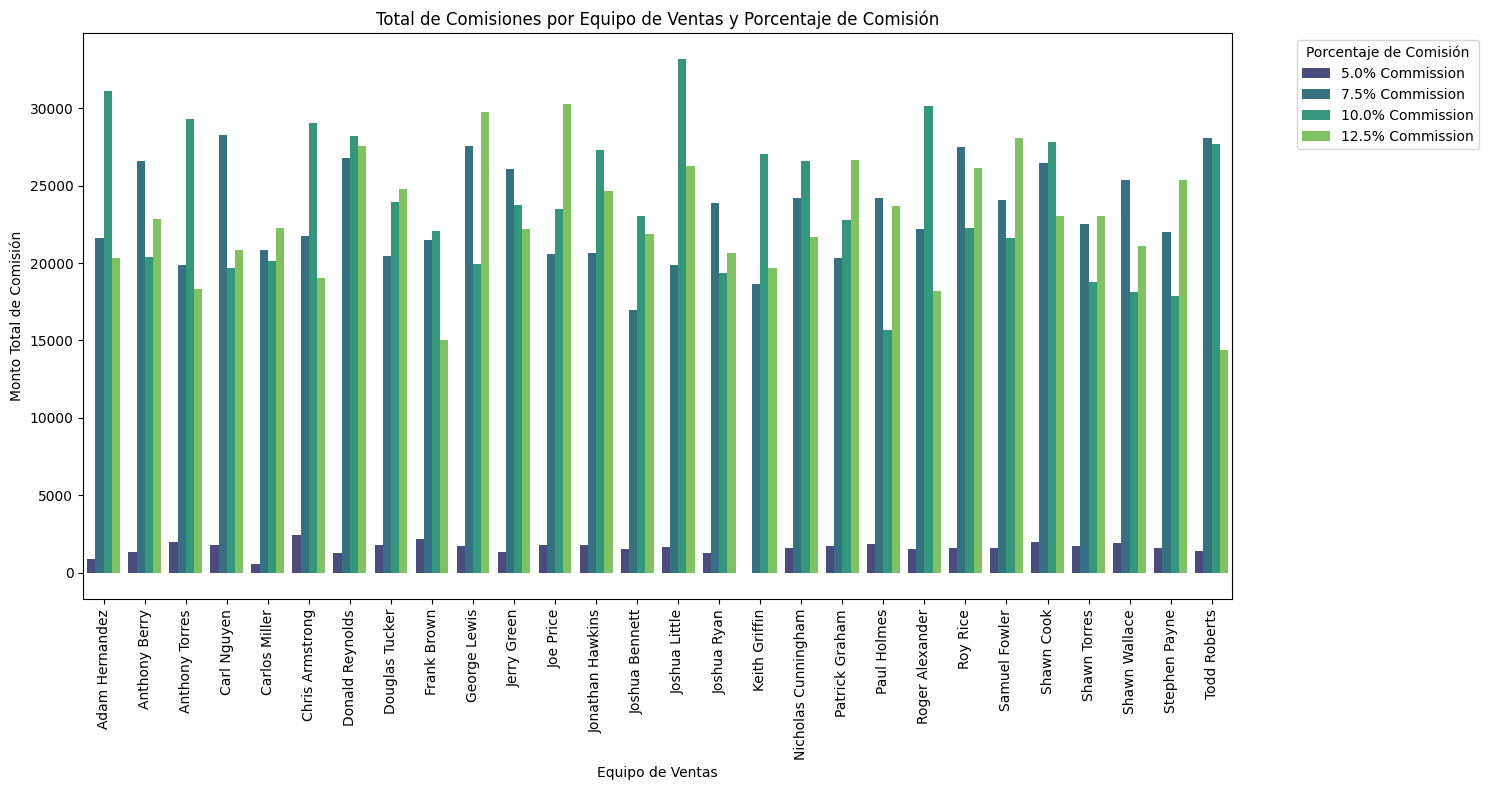

In [45]:
# Visualización de Reporte 2

# Apilar el DataFrame para facilitar la visualización con seaborn
reporte2_stacked = reporte2_pivot.stack().reset_index()
reporte2_stacked.columns = ['Sales Team', 'Commissions Percentage', 'Total Commission Amount']

plt.figure(figsize=(15, 8))
sns.barplot(
    data=reporte2_stacked,
    x='Sales Team',
    y='Total Commission Amount',
    hue='Commissions Percentage',
    palette='viridis'
)
plt.title('Total de Comisiones por Equipo de Ventas y Porcentaje de Comisión')
plt.xlabel('Equipo de Ventas')
plt.ylabel('Monto Total de Comisión')
plt.xticks(rotation=90) # Rotar etiquetas del eje X para mayor legibilidad
plt.legend(title='Porcentaje de Comisión', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# 8.  Calcula el monto de la comisión, utilizando la Tabla del Anexo.
KPI Cálculo
CommissionsAmount GrossMargin*CommissionsPercentage

In [ ]:
# respondido junto con la pregunta 7

In [ ]:
# 9. Calcula la comisión sobre el margen bruto.
KPI       Cálculo
NetMargin GrossMargin-CommissionsAmount

In [46]:
# 9. Calcular la comisión sobre el margen bruto (NetMargin)
df_base['NetMargin'] = df_base['GrossMargin'] - df_base['CommissionAmount']

print("=== df_base con la nueva columna NetMargin ===")
display(df_base[['OrderNumber', 'GrossMargin', 'CommissionAmount', 'NetMargin']].head())

=== df_base con la nueva columna NetMargin ===


,OrderNumber,GrossMargin,CommissionAmount,NetMargin
0,SO - 000101,4073.4325,305.507438,3767.925063
1,SO - 000102,886.4100,44.320500,842.089500
2,SO - 000103,905.5050,45.275250,860.229750
3,SO - 000104,5486.7640,548.676400,4938.087600
4,SO - 000105,1312.1280,98.409600,1213.718400


In [ ]:
# 10. Utilizando una tabla pivote, muestra la suma de los valores GrossMargin, NetMargin y
CommissionAmount agrupando por Sales Team en las filas. Este reporte debe cuadrar con
los datos de la pestaña Reporte2 del archivo reportes.xlsx

In [47]:
# 10. Crear la tabla pivote con la suma de GrossMargin, NetMargin y CommissionAmount
# agrupando por Sales Team.
reporte_final = pd.pivot_table(
    df_base,
    values=['GrossMargin', 'NetMargin', 'CommissionAmount'],
    index='Sales Team',
    aggfunc='sum',
    fill_value=0
)

print("=== Reporte Final: Suma de Márgenes y Comisiones por Equipo de Ventas ===")
display(reporte_final)

=== Reporte Final: Suma de Márgenes y Comisiones por Equipo de Ventas ===


,CommissionAmount,GrossMargin,NetMargin
Sales Team,,,
Adam Hernandez,73896.802450,779095.1955,705198.393050
Anthony Berry,71174.048075,767943.9500,696769.901925
Anthony Torres,69438.521113,743901.4355,674462.914388
Carl Nguyen,70478.542012,774781.4675,704302.925488
Carlos Miller,63811.258950,668752.9290,604941.670050
Chris Armstrong,72279.258300,781608.7005,709329.442200
Donald Reynolds,83846.778988,885386.8095,801540.030512
Douglas Tucker,70906.763300,745528.5640,674621.800700
Frank Brown,60748.339713,670881.2510,610132.911288
